In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pylab as plt 
import networkx as nx 
from projector import MDSTorusProjector

In [2]:
from matplotlib.patches import Polygon as MplPolygon

def torus_delta(p, q):
    """Shortest displacement from p to q on unit square torus (per-coordinate in [-0.5, 0.5))."""
    return ((q - p + 0.5) % 1.0) - 0.5

def torus_edge_segments(p, q, eps=1e-12):
    """
    Return list of (a_plot, b_plot) segments to draw the shortest torus geodesic between p and q,
    plotted in the fundamental domain [0,1]x[0,1], split at boundary crossings.

    p, q are assumed to be in [0,1)^2.
    """
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)

    d = torus_delta(p, q)
    r = p + d  # endpoint in covering space (may lie outside [0,1) )

    ts = [0.0, 1.0]

    # boundary crossings for each coordinate
    for k in (0, 1):
        dk = d[k]
        if abs(dk) < eps:
            continue

        # Determine which boundary is crossed (if any) based on direction and endpoint r
        if dk > 0 and r[k] > 1.0 + eps:
            b = 1.0
        elif dk < 0 and r[k] < 0.0 - eps:
            b = 0.0
        else:
            continue

        t = (b - p[k]) / dk
        if eps < t < 1.0 - eps:
            ts.append(float(t))

    ts = sorted(set(ts))

    segs = []
    for t0, t1 in zip(ts[:-1], ts[1:]):
        a = p + t0 * d
        b = p + t1 * d

        # Choose a single tile shift so BOTH endpoints land in the same plotted tile.
        mid = 0.5 * (a + b)
        tile = np.floor(mid)  # integer vector, typically in {-1,0,1}^2 here

        a_plot = a - tile
        b_plot = b - tile

        # Numerical guard: keep within [0,1] for plotting
        a_plot = np.clip(a_plot, 0.0, 1.0)
        b_plot = np.clip(b_plot, 0.0, 1.0)

        segs.append((a_plot, b_plot))

    return segs

def plot_embedding_with_torus_edges(X=None, G=None, outpath="output.png",
                                   s=10, node_alpha=0.9,
                                   edge_alpha=0.10, edge_lw=0.4,
                                   colors=None,
                                   torus=None,
                                   ax=None):
    """
    Scatter + edges drawn along shortest torus geodesics, displayed in physical space.

    X:     (N,2) embedding in [0,1)^2 parameter space (optional if torus is provided).
    G:     networkx graph
    torus: optional projector object. Reads torus_embedding_, alpha_, r0_, r1_, theta_
           to recover the physical geometry. theta_ defaults to pi/2 (rectangular).

    Physical lattice vectors (columns of M):
      e1 = (alpha*r0, 0)
      e2 = (alpha*r1*cos(theta), alpha*r1*sin(theta))
    All coordinates are mapped through M before plotting. Normal axes are hidden;
    tick marks with physical-unit labels are drawn directly on the parallelogram edges.
    """
    # Resolve embedding
    if X is None:
        if torus is None or torus.torus_embedding_ is None:
            raise ValueError("Provide either X or a fitted torus object with torus_embedding_.")
        X = torus.torus_embedding_

    X = np.asarray(X, dtype=np.float64) % 1.0
    idx = {n: i for i, n in enumerate(G.nodes())}

    # Physical side lengths: alpha * r; fall back to 1 if not available
    alpha = torus.alpha_ if (torus is not None and torus.alpha_ is not None) else 1.0
    r0 = alpha * (torus.r0_ if (torus is not None and torus.r0_ is not None) else 1.0)
    r1 = alpha * (torus.r1_ if (torus is not None and torus.r1_ is not None) else 1.0)
    theta = torus.theta_ if (torus is not None and hasattr(torus, 'theta_') and torus.theta_ is not None) else np.pi / 2

    # Lattice matrix: maps parameter coords (u,v) -> physical coords x = M @ [u,v]
    # e1 = (r0, 0),  e2 = (r1*cos(theta), r1*sin(theta))
    M = np.array([[r0, r1 * np.cos(theta)],
                  [0,  r1 * np.sin(theta)]])

    if ax is None:
        fig, ax = plt.subplots()

    # edges — segments computed in [0,1)^2, then mapped to physical space
    for u, v in G.edges():
        i, j = idx[u], idx[v]
        p, q = X[i], X[j]
        for a, b in torus_edge_segments(p, q):
            a_phys = M @ a
            b_phys = M @ b
            ax.plot([a_phys[0], b_phys[0]], [a_phys[1], b_phys[1]],
                     color="k", alpha=edge_alpha, lw=edge_lw, zorder=1)

    # points
    X_phys = X @ M.T
    ax.scatter(X_phys[:, 0], X_phys[:, 1], s=s, alpha=node_alpha, zorder=2,
               c=colors if colors is not None else "blue")

    # parallelogram boundary of the fundamental domain
    corners = np.array([[0, 0], [1, 0], [1, 1], [0, 1]]) @ M.T
    ax.add_patch(MplPolygon(corners, closed=True, fill=False,
                            edgecolor='gray', lw=1, zorder=3))

    ax.set_aspect('equal', adjustable='datalim')
    ax.axis('off')

    # --- Tick marks with physical-unit labels on parallelogram edges ---
    n_ticks   = 5
    tick_ts   = np.linspace(0, 1, n_ticks)
    tick_size = 0.025 * max(r0, r1)   # tick length in physical units
    pad       = 0.03  * max(r0, r1)   # gap between tick tip and label

    e1_perp = np.array([0.0, -1.0])                      # outward normal to bottom side
    e2_end  = M @ np.array([0.0, 1.0])                   # physical tip of e2
    e2_perp = np.array([-np.sin(theta), np.cos(theta)])  # outward normal to left side

    # Bottom side (e1): 5 ticks with labels showing physical distance from 0 to r0
    for t in tick_ts:
        pt = np.array([t * r0, 0.0])
        tip = pt + tick_size * e1_perp
        ax.plot([pt[0], tip[0]], [pt[1], tip[1]], color='dimgray', lw=0.8, zorder=4)
        lbl_pos = tip + pad * e1_perp
        ax.text(lbl_pos[0], lbl_pos[1], f"{t * r0:.3g}",
                ha='center', va='top', fontsize=8, color='dimgray')

    # Left side (e2): 5 ticks with labels showing physical distance from 0 to r1.
    # Skip the t=0 label — already covered by the "0" on the bottom side.
    for t in tick_ts:
        pt = t * e2_end
        tip = pt + tick_size * e2_perp
        ax.plot([pt[0], tip[0]], [pt[1], tip[1]], color='dimgray', lw=0.8, zorder=4)
        if t > 0:
            lbl_pos = tip + pad * e2_perp
            ax.text(lbl_pos[0], lbl_pos[1], f"{t * r1:.3g}",
                    ha='center', va='center', rotation=np.degrees(theta),
                    fontsize=8, color='dimgray')

    plt.tight_layout()
    return ax

def periodic_lattice_graph(nx_size: int, ny_size: int, diagonal: bool = False) -> nx.Graph:
    """
    Create a 2D periodic lattice (torus) graph with NetworkX.

    Nodes are (i, j) tuples. Periodic boundaries wrap in both directions.
    If diagonal=True, add 4 diagonal neighbors (8-neighborhood total).
    """
    G = nx.grid_2d_graph(nx_size, ny_size, periodic=True)

    if diagonal:
        # Add diagonal wrap-around edges
        for i in range(nx_size):
            for j in range(ny_size):
                G.add_edge((i, j), ((i + 1) % nx_size, (j + 1) % ny_size))
                G.add_edge((i, j), ((i + 1) % nx_size, (j - 1) % ny_size))

    # Unit weights (optional but explicit)
    nx.set_edge_attributes(G, 1.0, "weight")
    return G


In [3]:
def apsp_distance_matrix(G: nx.Graph, weight: str = "weight") -> tuple[np.ndarray, list]:
    """
    Compute all-pairs shortest path (APSP) distance matrix using NetworkX.

    Returns:
    D: (N,N) float64 distance matrix
    nodes: list of nodes in the order used for D
    """
    nodes = list(G.nodes())
    idx = {n: k for k, n in enumerate(nodes)}
    n = len(nodes)
    D = np.zeros((n, n), dtype=np.float64)

    # all_pairs_dijkstra_path_length works for unit weights too
    for src, dist_dict in nx.all_pairs_dijkstra_path_length(G, weight=weight):
        i = idx[src]
        for dst, d in dist_dict.items():
            D[i, idx[dst]] = float(d)

    return D, nodes

def get_periodic_lattice(nx_size=20,ny_size=20):

    G = periodic_lattice_graph(nx_size, ny_size, diagonal=False)
    D, nodes = apsp_distance_matrix(G)
    return G,D

## Lattice graph

<Axes: >

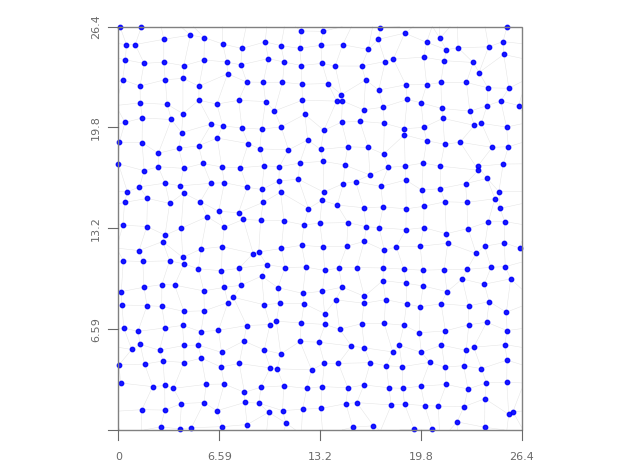

In [4]:
G, D = get_periodic_lattice(20, 20)

#Normalize or don't
# D /= np.max(D)

proj = MDSTorusProjector()
proj.fit_transform(D)

fig, ax = plt.subplots()
plot_embedding_with_torus_edges(G=G, torus=proj, ax=ax)


### 20×20 grid: comparing learn modes

[alpha]  alpha=26.36
[square]  r=26.37
[rectangular]  r0=26.36  r1=26.37  ratio=1.000


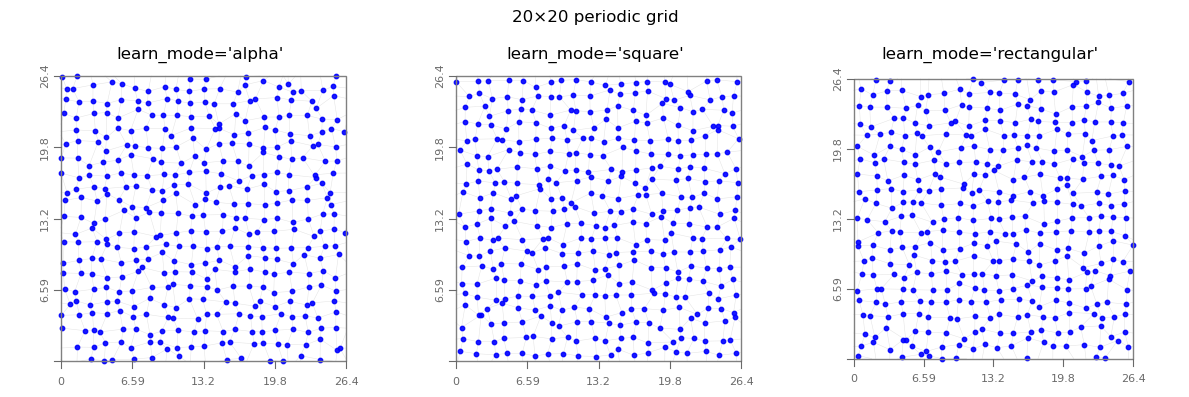

In [5]:
G20, D20 = get_periodic_lattice(20, 20)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, mode in zip(axes, ['alpha', 'square', 'rectangular']):
    proj = MDSTorusProjector()
    proj.fit_transform(D20, learn_mode=mode)
    if mode == 'alpha':
        print(f"[{mode}]  alpha={proj.alpha_:.4g}")
    elif mode == 'square':
        print(f"[{mode}]  r={proj.r0_:.4g}")
    else:
        print(f"[{mode}]  r0={proj.r0_:.4g}  r1={proj.r1_:.4g}  ratio={proj.r1_/proj.r0_:.3f}")
    plot_embedding_with_torus_edges(G=G20, torus=proj, ax=ax)
    ax.set_title(f"learn_mode='{mode}'")
plt.suptitle("20×20 periodic grid")
plt.tight_layout()


## 20×40 periodic grid

In [6]:
G40, D40 = get_periodic_lattice(20, 40)
colors = [j for (i, j) in G40.nodes()]  # varies along the long (40-node) direction
colors_short = [i for (i, j) in G40.nodes()]  # varies along the long (40-node) direction


[alpha]  alpha=39.1
[square]  r=39.07
[rectangular]  r0=39.16  r1=38.95  ratio=0.995


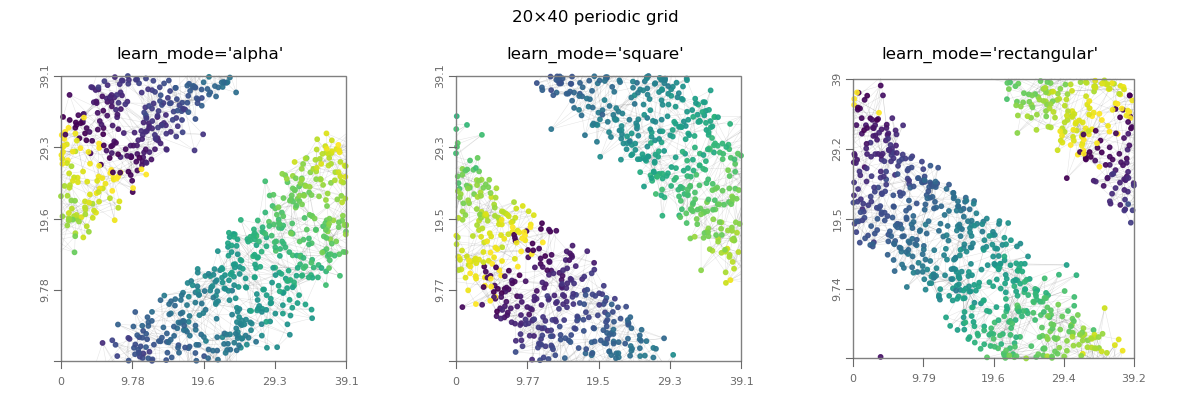

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, mode in zip(axes, ['alpha', 'square', 'rectangular']):
    proj = MDSTorusProjector()
    proj.fit_transform(D40, learn_mode=mode)
    if mode == 'alpha':
        print(f"[{mode}]  alpha={proj.alpha_:.4g}")
    elif mode == 'square':
        print(f"[{mode}]  r={proj.r0_:.4g}")
    else:
        print(f"[{mode}]  r0={proj.r0_:.4g}  r1={proj.r1_:.4g}  ratio={proj.r1_/proj.r0_:.3f}")
    plot_embedding_with_torus_edges(G=G40, torus=proj, ax=ax, colors=colors)
    ax.set_title(f"learn_mode='{mode}'")
plt.suptitle("20×40 periodic grid")
plt.tight_layout()
# --> different aspect ratio leads to diagonal embeddings even in the rectangular mode. This might be an initialization issue as the torus is initialized as a square.


### 20×40 grid: fixed 1:2 ratio, learn scale only (sanity check)

[fixed ratio]    alpha=25.13  r0=1  r1=2
[learned ratio]  alpha=1  r0=32.42  r1=45.86  ratio=1.415


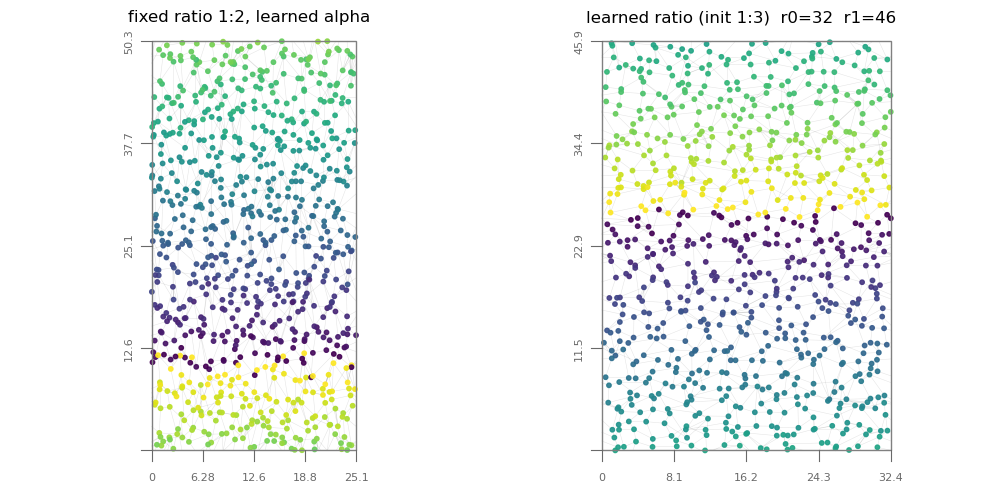

In [8]:
colors = [j for (i, j) in G40.nodes()]  # varies along the long (40-node) direction

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Panel 1: fixed 1:2 ratio, learn scale only
proj = MDSTorusProjector()
proj.fit_transform(D40, learn_mode='alpha', r0_init=1.0, r1_init=2.0)
print(f"[fixed ratio]    alpha={proj.alpha_:.4g}  r0={proj.r0_:.4g}  r1={proj.r1_:.4g}")
plot_embedding_with_torus_edges(G=G40, torus=proj, ax=axes[0], colors=colors)
axes[0].set_title("fixed ratio 1:2, learned alpha")

# Panel 2: learn r0/r1 freely, start at 1:3 (neither 1:1 nor 1:2)
proj = MDSTorusProjector()
proj.fit_transform(D40, learn_mode='rectangular', r0_init=25.0, r1_init=50.0)
print(f"[learned ratio]  alpha={proj.alpha_:.4g}  r0={proj.r0_:.4g}  r1={proj.r1_:.4g}  ratio={proj.r1_/proj.r0_:.3f}")
plot_embedding_with_torus_edges(G=G40, torus=proj, ax=axes[1], colors=colors)
axes[1].set_title(f"learned ratio (init 1:3)  r0={proj.r0_:.2g}  r1={proj.r1_:.2g}")

plt.tight_layout()
# --> given the correct fixed aspect ratio, the long periodic lattice correctly orients itself.
# --> when initializing anisotropically, we maintain an anisotropic solution, but not with ratio 1:2
# --> which has lower stress?


## Grid cells

In [6]:
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA

a = np.load("grid_cells_4800.npz")
data = a['data']
spikes = a['spikes']


D = pairwise_distances(data)

X = MDSTorusProjector().fit_transform(D)



Text(0.5, 0.98, 'Firing rates of selected cells by spatial position\n Toroidal embedding')

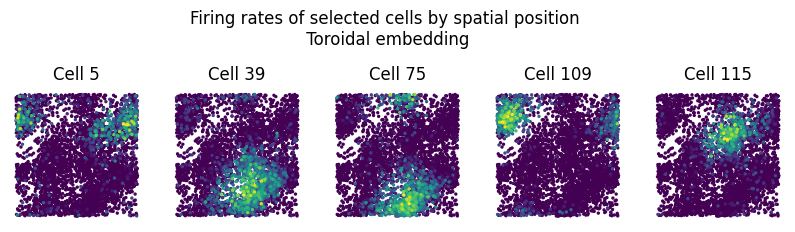

In [7]:
# spatial location of firing rates
fig, ax = plt.subplots(1, 5, figsize=(10, 3))

cell_ids = [5, 39, 75, 109, 115] # cells with clearly structured firing pattern

xx = X[:,0]
yy = X[:,1]
for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    ax[i].scatter(xx[order], yy[order], c=spikes[order, idx], s=2)
    ax[i].set_title(f"Cell {idx}")
    ax[i].axis("off")
    ax[i].set_aspect("equal")
fig.suptitle("Firing rates of selected cells by spatial position\n Toroidal embedding")

## Yoda and Bulldog

In [ ]:
pca = np.load("yoda_bulldog_pca50.npy")

D = pairwise_distances(pca[:,:10])
X = MDSTorusProjector().fit_transform(D)

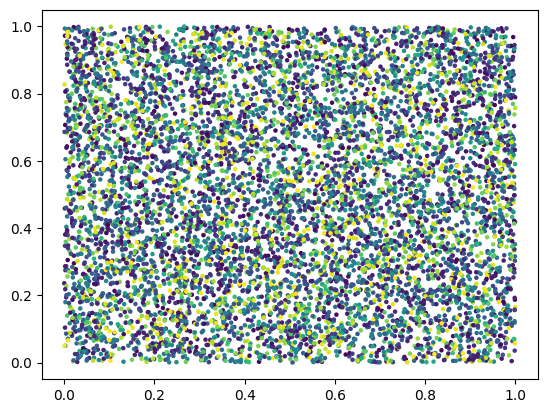

In [18]:
fig, ax = plt.subplots()
plt.scatter(X[:,0], X[:,1],c=pca[:,1],s=5)

## Block models

In [13]:
G = nx.planted_partition_graph(5, 100, 0.2, 0.01)
d, nodes = apsp_distance_matrix(G)

X_torus = MDSTorusProjector().fit_transform(d)

<Axes: >

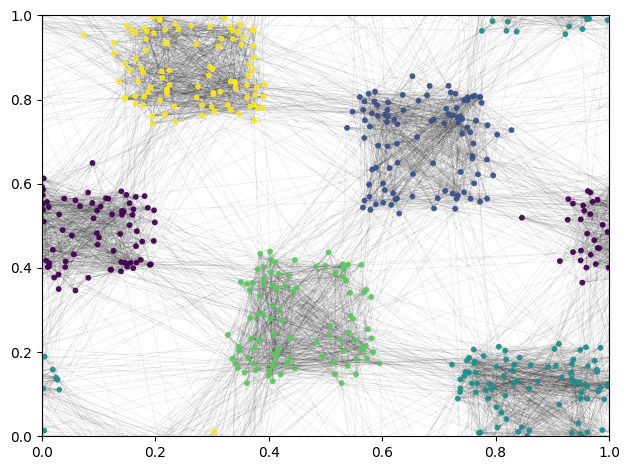

In [16]:
colors = [0] * 100 + [1] * 100 + [2] * 100 + [3] * 100 + [4] * 100
plot_embedding_with_torus_edges(X_torus,G,colors=colors)

## Rhombic torus (theta = 60°)

alpha=24.92  r0=1  r1=1


Text(0.5, 1.0, '20×20 grid, rhombic torus θ=60°')

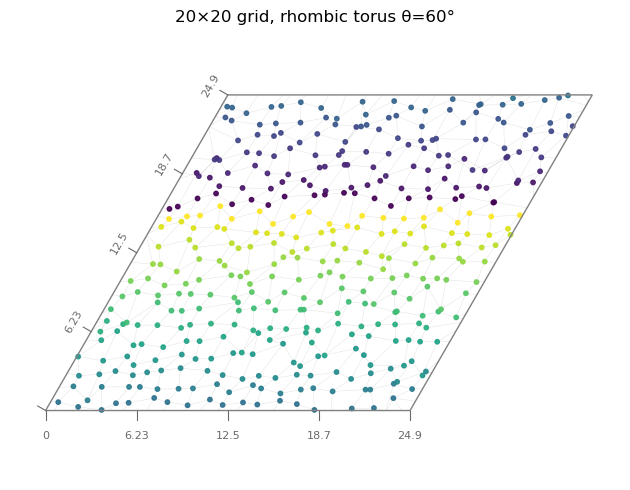

In [9]:
# 20×20 periodic grid embedded on a rhombic torus with theta=60°
G20, D20 = get_periodic_lattice(20, 20)
colors20 = [i for (i, j) in G20.nodes()]  # color by row index

proj = MDSTorusProjector()
proj.fit_transform(D20, learn_mode='alpha', theta=60.0)
print(f"alpha={proj.alpha_:.4g}  r0={proj.r0_:.4g}  r1={proj.r1_:.4g}")

fig, ax = plt.subplots()
plot_embedding_with_torus_edges(G=G20, torus=proj, ax=ax, colors=colors20)
ax.set_title("20×20 grid, rhombic torus θ=60°")

alpha=2.251  r0=1  r1=1


Text(0.5, 1.0, 'K7, rhombic torus θ=60°')

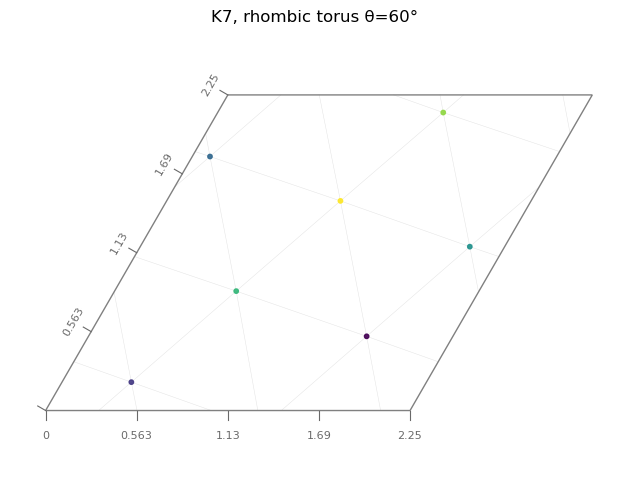

In [10]:
# K7 (complete graph on 7 nodes) embedded on the same rhombic torus (theta=60°)
# All pairwise graph distances = 1; the rhombic torus should admit an equidistant embedding.
K7 = nx.complete_graph(7)
D_K7, _ = apsp_distance_matrix(K7)

proj_k7 = MDSTorusProjector()
proj_k7.fit_transform(D_K7, learn_mode='alpha', theta=60.0)
print(f"alpha={proj_k7.alpha_:.4g}  r0={proj_k7.r0_:.4g}  r1={proj_k7.r1_:.4g}")

fig, ax = plt.subplots()
plot_embedding_with_torus_edges(G=K7, torus=proj_k7, ax=ax, colors=list(range(7)))
ax.set_title("K7, rhombic torus θ=60°")

alpha=5.691  r0=1  r1=1


Text(0.5, 1.0, '7-block SBM (7×50 nodes), rhombic torus θ=60°')

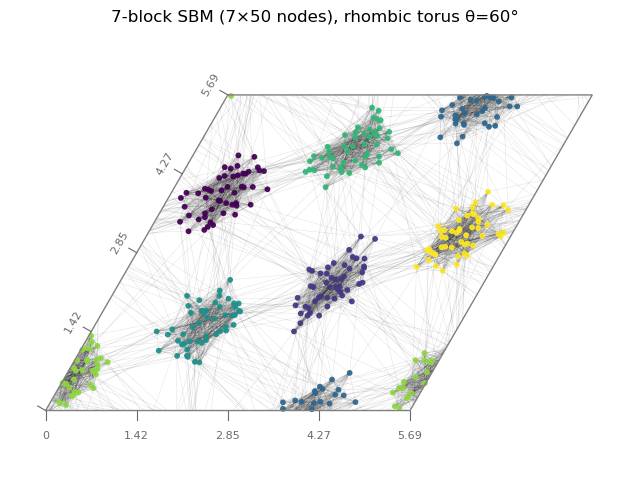

In [11]:
# 7-block stochastic block model embedded on the rhombic torus (theta=60°)
# 7 communities -> quotient graph ~ K7 -> should place communities at K7 vertices
k = 50  # nodes per block
G_sbm = nx.planted_partition_graph(7, k, 0.5, 0.01, seed=0)
D_sbm, _ = apsp_distance_matrix(G_sbm)

proj_sbm = MDSTorusProjector()
proj_sbm.fit_transform(D_sbm, learn_mode='alpha', theta=60.0)
print(f"alpha={proj_sbm.alpha_:.4g}  r0={proj_sbm.r0_:.4g}  r1={proj_sbm.r1_:.4g}")

colors_sbm = [b for b in range(7) for _ in range(k)]
fig, ax = plt.subplots()
plot_embedding_with_torus_edges(G=G_sbm, torus=proj_sbm, ax=ax, colors=colors_sbm)
ax.set_title("7-block SBM (7×50 nodes), rhombic torus θ=60°")

# --> unclear why the clusters appear sheared. Should they not be round-ish?